In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [ ]:
drive.mount("/content/drive")
data = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/data_amazon.csv")

data.head()

Mounted at /content/drive


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [ ]:
print(f"Розмір датасету: {data.shape[0]} x {data.shape[1]}")
data_nd = data.drop_duplicates(subset=["Name"])
print(f"Розмір датасету без дублікатів: {data_nd.shape[0]} x {data_nd.shape[1]}")
print(f"Відповідь: в датасеті {data_nd.shape[0]} книг")

Розмір датасету: 550 x 7
Розмір датасету без дублікатів: 351 x 7
Відповідь: в датасеті 351 книг


In [ ]:
data.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
spaces = data.isna().sum()
def is_spaces(arr: pd.Series):
  for i in arr:
    if i != 0:
      return "так пропуски є."
  return "ні пропусків нема."
print(f"Відповідь: {is_spaces(spaces)}")

Відповідь: ні пропусків нема.


In [ ]:
gnr = data['genre'].unique()
gnr = ", ".join(gnr)
print(f"Відповідь - унікальні жанри: {gnr}")

Відповідь - унікальні жанри: Non Fiction, Fiction


In [ ]:
#Тут вказано побудувати діаграму розподілу цін, але не вказано за яким показником, далі є діаграми розподілу за рейтингом і переглядами
max = data['price'].max()
min = data['price'].min()
mean = data['price'].mean()
med = data['price'].median()
print(f"Відповідь: максимальна ціна - {max}")
print(f"Відповідь: мінімальна ціна - {min}")
print(f"Відповідь: середня ціна - {mean}")
print(f"Відповідь: медіанна ціна - {med}")

Відповідь: максимальна ціна - 105
Відповідь: мінімальна ціна - 0
Відповідь: середня ціна - 13.1
Відповідь: медіанна ціна - 11.0


In [ ]:
data_r = data[data['user_rating'] == data['user_rating'].max()]
data_n = data[data['reviews'] == data['reviews'].max()]
data_2015 = data[data['year'] == 2015].sort_values("user_rating", ascending=False)[:50]
data_2015_fic = data[(data['year'] == 2015) & (data['genre'] == "Fiction")].sort_values("user_rating", ascending=False)[:50]
data_4_9 = data[(data['year'].isin([2010, 2011])) & (data['user_rating'] == 4.9)]
# Тут не вказано за якою властивістю сортувати, тому залишив за рейтингом
data_2015_8 = data[(data['year'] == 2015) & (data['price'] == 8)].sort_values("user_rating")
print(f"Відповідь: найвищий рейтинг {data['user_rating'].max()}")
print(f"Відповідь: такий рейтинг мають {data_r.shape[0]} книг")
print(f"Відповідь: книга з найбільшою кількістю відгуків - {data_n.iloc[0]['name']}")
print(f"Відповідь: найдорожча з топ 50 у 2015 році - {data_2015[data_2015['price'] == data_2015['price'].max()].iloc[0]['name']}")
print(f"Відповідь: до топ 50 у 2015 році потрапило {data_2015_fic.shape[0]} книг жанру 'Fiction'")
print(f"Відповідь: книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках - {data_4_9.shape[0]}")
print(f"Відповідь: остання книга зi списку - {data_2015_8.iloc[-1]["name"]}")

Відповідь: найвищий рейтинг 4.9
Відповідь: такий рейтинг мають 52 книг
Відповідь: книга з найбільшою кількістю відгуків - Where the Crawdads Sing
Відповідь: найдорожча з топ 50 у 2015 році - Publication Manual of the American Psychological Association, 6th Edition
Відповідь: до топ 50 у 2015 році потрапило 17 книг жанру 'Fiction'
Відповідь: книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках - 1
Відповідь: остання книга зi списку - Oh, the Places You'll Go!


In [ ]:
data_g = pd.DataFrame({
    "genre": data['genre'],
    "price": data['price']
})
data_g = data_g.groupby('genre')["price"].agg(["min", "max"])
print(f"Максимальна ціна для жанру Fiction: {data_g.iloc[0]['max']}")
print(f"Мінімальна ціна для жанру Fiction: {data_g.iloc[1]['min']}")
print(f"Максимальна ціна для жанру Non Fiction: {data_g.iloc[0]['max']}")
print(f"Мінімальна ціна для жанру Fiction: {data_g.iloc[1]['min']}")
data_g

Максимальна ціна для жанру Fiction: 82
Мінімальна ціна для жанру Fiction: 0
Максимальна ціна для жанру Non Fiction: 82
Мінімальна ціна для жанру Fiction: 0


,min,max
genre,,
Fiction,0,82
Non Fiction,0,105


In [ ]:
data_author = data.groupby('author')["name"].agg(["count"]).sort_values("count", ascending=False)
print(f"Нова розмірність таблиці: {data_author.shape[0]} x {data_author.shape[1]}")
print(f"Найбільше книг у {data_author.index[0]}")
print(f"Автор має {data_author.iloc[0]["count"]} книг")

Нова розмірність таблиці: 248 x 1
Найбільше книг у Jeff Kinney
Автор має 12 книг


In [ ]:
data_rating = data.groupby('author')["user_rating"].agg(["mean"]).round(1).sort_values("mean")
print(f"Мінімальний середній рейтинг у {data_rating.index[0]}")
print(f"Він складає {data_rating.iloc[0]["mean"]}")

Мінімальний середній рейтинг у Donna Tartt
Він складає 3.9


In [ ]:
data_new = pd.concat([data_author, data_rating], axis=1)
data_new.columns = ['count_books', 'average_rating']
data_new = data_new.sort_values(['count_books', 'average_rating'])
print(f"Тепер перший в списку - {data_new.index[0]}")

Тепер перший в списку - Muriel Barbery


**Візуалізація**

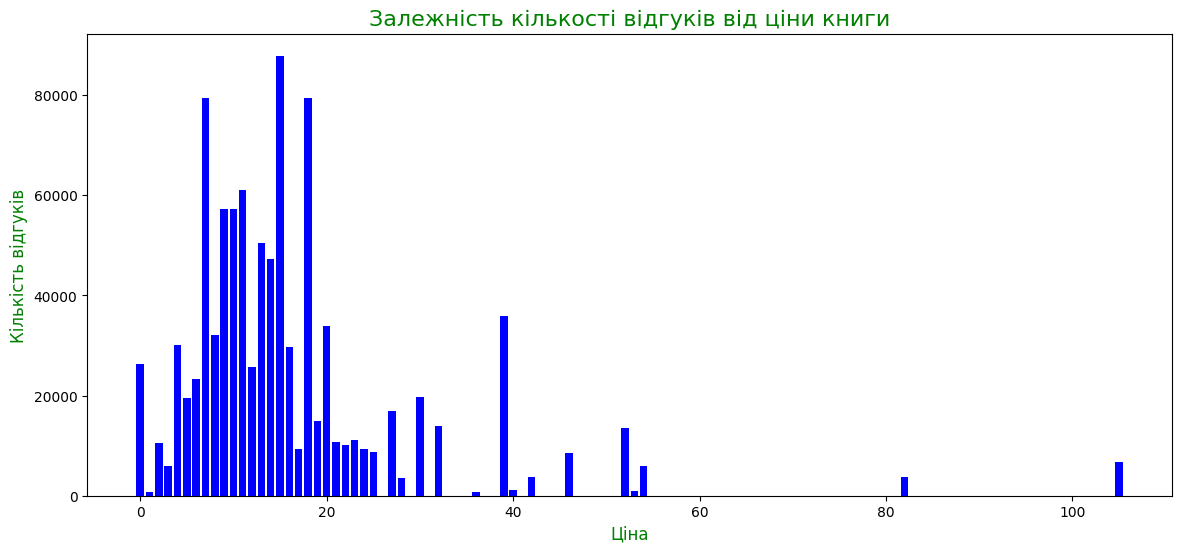

In [ ]:
plt.figure(figsize=(14, 6))
plt.bar(data['price'], data['reviews'], color='blue')
plt.title("Залежність кількості відгуків від ціни книги", color='green', fontsize = 16)
plt.ylabel("Кількість відгуків", color='green', fontsize=12)
plt.xlabel("Ціна", color='green', fontsize=12)
plt.show()

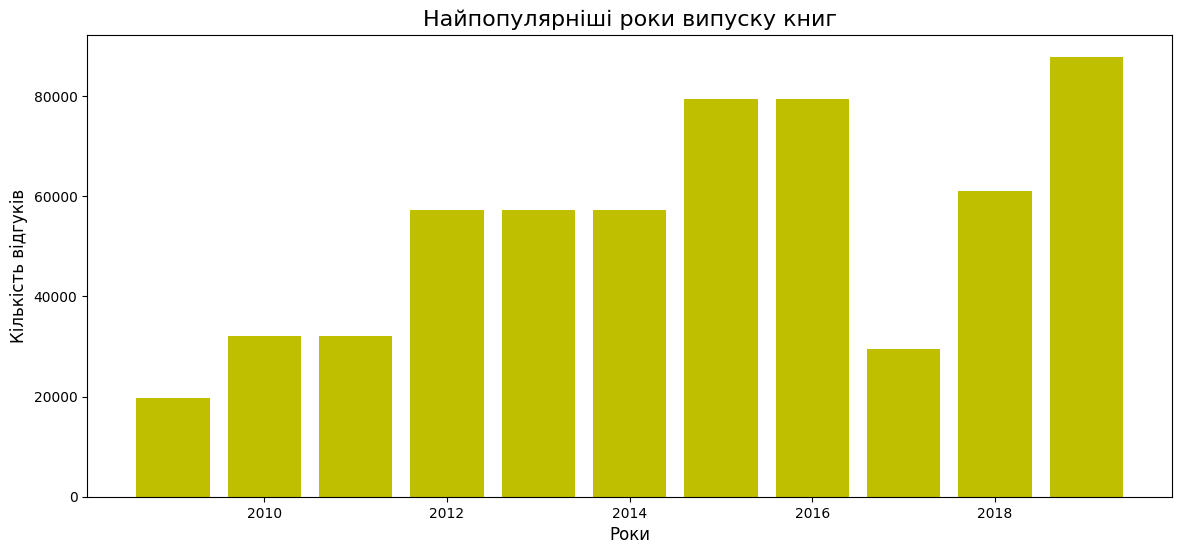

In [ ]:
plt.figure(figsize=(14, 6))
plt.bar(data['year'], data['reviews'], color='y')
plt.title("Найпопулярніші роки випуску книг", fontsize = 16)
plt.ylabel("Кількість відгуків", fontsize=12)
plt.xlabel("Роки", fontsize=12)
plt.show()

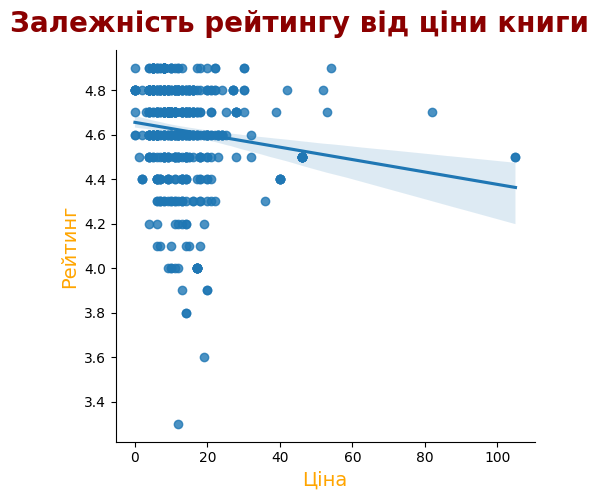

In [ ]:
#sns.scatterplot(x='price', y='user_rating', data=data)
g = sns.lmplot(x='price', y='user_rating', data=data)
g.set_axis_labels(
    'Цiна',
    'Рейтинг',
    fontsize=14,
    color='orange'
)
g.fig.suptitle(
    'Залежність рейтингу від ціни книги',
    fontsize=20,
    color='darkred',
    fontweight='bold'
)
g.fig.subplots_adjust(top=0.9)